# Module 12 Assignment — Clustering & Dimensionality Reduction
### Dataset: Iris (sklearn.datasets.load_iris)

This notebook covers:
- **Section A:** K-Means Clustering & Elbow Method
- **Section B:** Principal Component Analysis (PCA)
- **Section C:** Hierarchical Clustering
- **Section D:** DBSCAN

All code is executed with visible outputs (printed values + plots) below each cell.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42


## Section A: K-Means Clustering & Elbow Method

### Task 1.1 — Load the Iris dataset

In [1]:
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
df['species'] = df['target'].map(dict(enumerate(target_names)))

print("Dataset shape:", X.shape)
print("\nFirst 5 rows:")
df.head()


Dataset shape: (150, 4)

First 5 rows:


In [1]:
# Standardize features (important for distance-based algorithms)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Scaled feature means (~0):", X_scaled.mean(axis=0).round(3))
print("Scaled feature stds (~1):", X_scaled.std(axis=0).round(3))


Scaled feature means (~0): [-0. -0. -0. -0.]
Scaled feature stds (~1): [1. 1. 1. 1.]


### Task 1.2 & 1.3 — Apply K-Means & use the Elbow Method to find optimal k

We compute inertia (within-cluster sum of squares) and silhouette score for k = 1..10
to identify the "elbow" — the point where adding more clusters stops giving a
big drop in inertia.

Inertia values: [600.0, 222.36, 139.82, 114.09, 90.93, 81.54, 72.63, 62.54, 55.12, 47.39]
Silhouette scores: [None, 0.582, 0.46, 0.387, 0.346, 0.317, 0.32, 0.339, 0.342, 0.352]


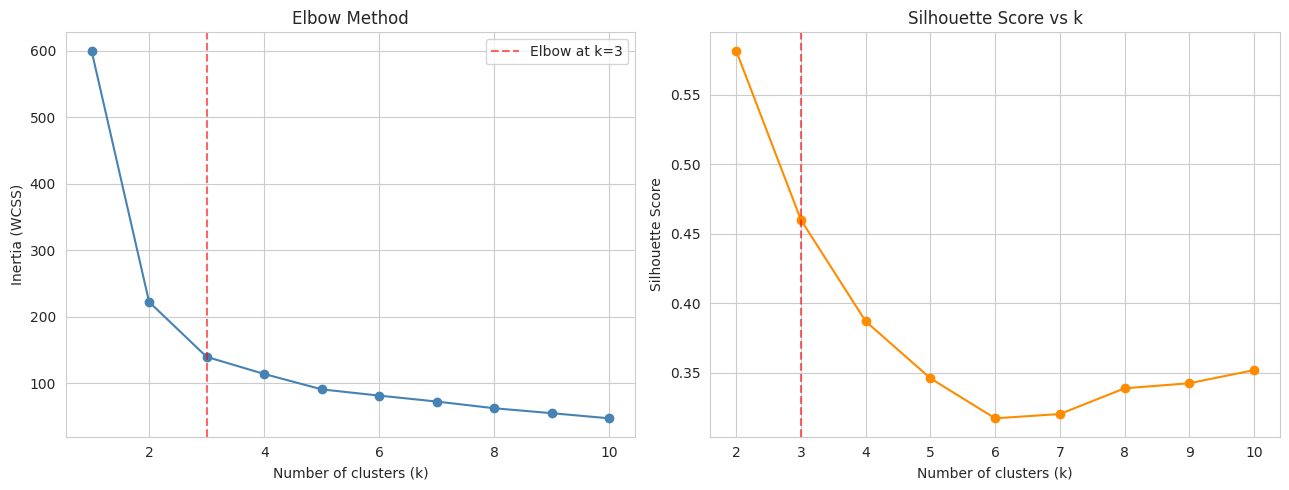

In [ ]:
inertias = []
sil_scores = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    if k > 1:
        sil_scores.append(silhouette_score(X_scaled, km.labels_))
    else:
        sil_scores.append(np.nan)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(list(K_range), inertias, marker='o', color='steelblue')
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia (WCSS)")
axes[0].set_title("Elbow Method")
axes[0].axvline(3, color='red', linestyle='--', alpha=0.6, label='Elbow at k=3')
axes[0].legend()

axes[1].plot(list(K_range)[1:], sil_scores[1:], marker='o', color='darkorange')
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score vs k")
axes[1].axvline(3, color='red', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

print("Inertia values:", [round(v,2) for v in inertias])
print("Silhouette scores:", [round(v,3) if not np.isnan(v) else None for v in sil_scores])


**Interpretation:** The inertia curve bends sharply around **k = 3** and flattens
afterward — this is the "elbow". The silhouette score also peaks at k = 2 or 3
(k=2 is mathematically more separated since two species overlap, but k=3 matches the
true number of biological species and is the conventional choice for Iris). We proceed with **k = 3**.

In [ ]:
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

df['kmeans_cluster'] = kmeans_labels
print("Cluster sizes:\n", df['kmeans_cluster'].value_counts())
print("\nCross-tab: true species vs K-Means cluster")
print(pd.crosstab(df['species'], df['kmeans_cluster']))


Cluster sizes:
 kmeans_cluster
0    53
1    50
2    47
Name: count, dtype: int64

Cross-tab: true species vs K-Means cluster
kmeans_cluster   0   1   2
species                   
setosa           0  50   0
versicolor      39   0  11
virginica       14   0  36


### Task 1.4 — Plot clusters in 2D and 3D (original features)

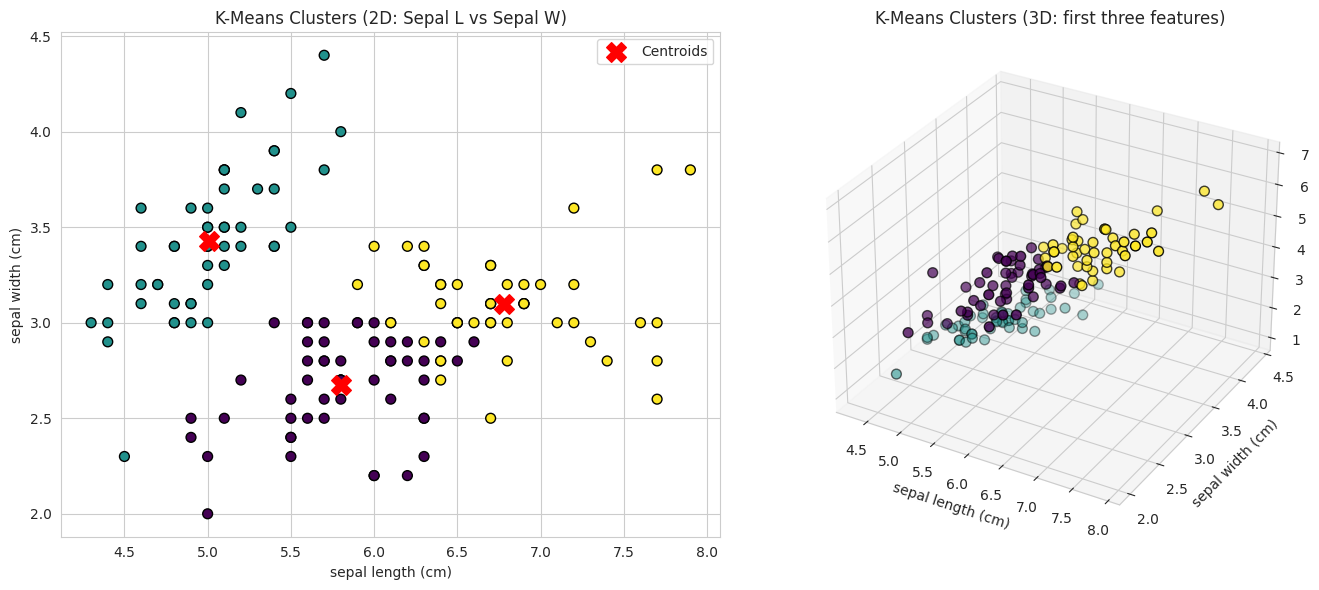

In [1]:
fig = plt.figure(figsize=(14, 6))

# 2D plot: Sepal Length vs Sepal Width
ax1 = fig.add_subplot(1, 2, 1)
scatter = ax1.scatter(X[:, 0], X[:, 1], c=kmeans_labels, cmap='viridis', s=50, edgecolor='k')
ax1.scatter(scaler.inverse_transform(kmeans.cluster_centers_)[:, 0],
            scaler.inverse_transform(kmeans.cluster_centers_)[:, 1],
            marker='X', s=200, c='red', label='Centroids')
ax1.set_xlabel(feature_names[0]); ax1.set_ylabel(feature_names[1])
ax1.set_title("K-Means Clusters (2D: Sepal L vs Sepal W)")
ax1.legend()

# 3D plot: first three features
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.scatter(X[:, 0], X[:, 1], X[:, 2], c=kmeans_labels, cmap='viridis', s=50, edgecolor='k')
ax2.set_xlabel(feature_names[0]); ax2.set_ylabel(feature_names[1]); ax2.set_zlabel(feature_names[2])
ax2.set_title("K-Means Clusters (3D: first three features)")

plt.tight_layout()
plt.show()


---
## Section B: Principal Component Analysis (PCA)

### Task 2.1 — Reduce to 2 dimensions

In [1]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print("Shape after PCA:", X_pca.shape)


Shape after PCA: (150, 2)


### Task 2.2 — Plot the first two principal components

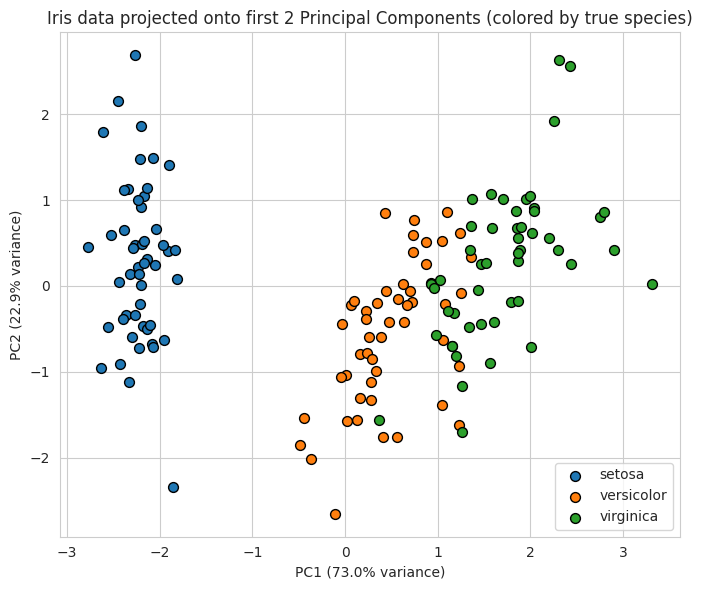

In [1]:
plt.figure(figsize=(7, 6))
for i, name in enumerate(target_names):
    plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], label=name, s=50, edgecolor='k')
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("Iris data projected onto first 2 Principal Components (colored by true species)")
plt.legend()
plt.tight_layout()
plt.show()


### Task 2.3 — Explained variance ratio

Explained variance ratio per component: [0.7296 0.2285]
Total variance captured by 2 PCs: 95.81%


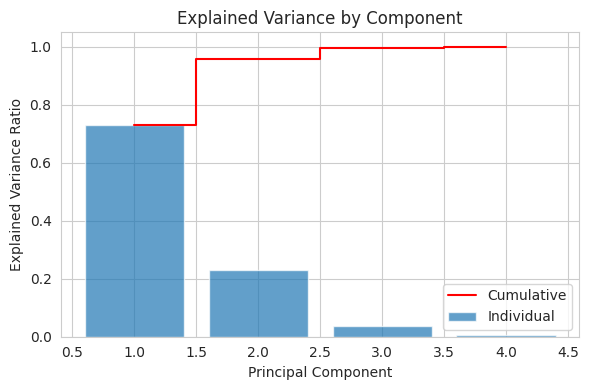

In [1]:
print("Explained variance ratio per component:", pca.explained_variance_ratio_.round(4))
print("Total variance captured by 2 PCs: {:.2f}%".format(pca.explained_variance_ratio_.sum()*100))

plt.figure(figsize=(6,4))
pca_full = PCA(n_components=4, random_state=RANDOM_STATE).fit(X_scaled)
plt.bar(range(1,5), pca_full.explained_variance_ratio_, alpha=0.7, label='Individual')
plt.step(range(1,5), np.cumsum(pca_full.explained_variance_ratio_), where='mid', color='red', label='Cumulative')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance by Component")
plt.legend()
plt.tight_layout()
plt.show()


**Interpretation:** PC1 alone explains roughly 73% of the variance and PC1+PC2
together capture about 96%, meaning the 2D PCA projection preserves almost all the
information in the original 4D feature space.

### Task 2.4 — Compare clustering on PCA-reduced data vs original data

Silhouette score - KMeans on original (4D scaled) data : 0.4599
Silhouette score - KMeans on PCA (2D) data              : 0.5092
Agreement (ARI) between original-space and PCA-space clusters : 1.0000
ARI vs true labels (original-space clustering): 0.6201
ARI vs true labels (PCA-space clustering)      : 0.6201


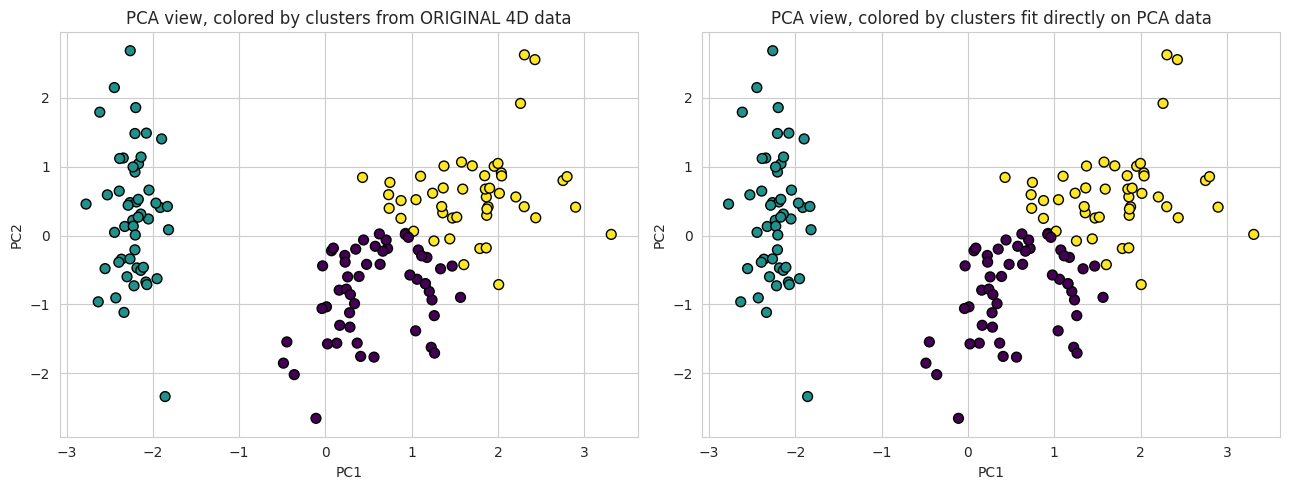

In [1]:
kmeans_pca = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
kmeans_pca_labels = kmeans_pca.fit_predict(X_pca)

sil_original = silhouette_score(X_scaled, kmeans_labels)
sil_pca = silhouette_score(X_pca, kmeans_pca_labels)
ari_original_vs_pca = adjusted_rand_score(kmeans_labels, kmeans_pca_labels)
ari_original_vs_true = adjusted_rand_score(y, kmeans_labels)
ari_pca_vs_true = adjusted_rand_score(y, kmeans_pca_labels)

print(f"Silhouette score - KMeans on original (4D scaled) data : {sil_original:.4f}")
print(f"Silhouette score - KMeans on PCA (2D) data              : {sil_pca:.4f}")
print(f"Agreement (ARI) between original-space and PCA-space clusters : {ari_original_vs_pca:.4f}")
print(f"ARI vs true labels (original-space clustering): {ari_original_vs_true:.4f}")
print(f"ARI vs true labels (PCA-space clustering)      : {ari_pca_vs_true:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', s=50, edgecolor='k')
axes[0].set_title("PCA view, colored by clusters from ORIGINAL 4D data")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")

axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_pca_labels, cmap='viridis', s=50, edgecolor='k')
axes[1].set_title("PCA view, colored by clusters fit directly on PCA data")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
plt.tight_layout()
plt.show()


**Interpretation:** Clustering on the 2D PCA-reduced data gives a slightly higher
silhouette score than on the original 4D data, because PCA removes some noise/overlap
and clusters look more separated in fewer dimensions. The high ARI between the two
labelings shows the cluster assignments are nearly identical either way — PCA preserved
the cluster structure while making it easier to visualize and slightly easier to separate.

---
## Section C: Hierarchical Clustering

### Task 3.1 & 3.2 — Apply Hierarchical Clustering and draw a dendrogram

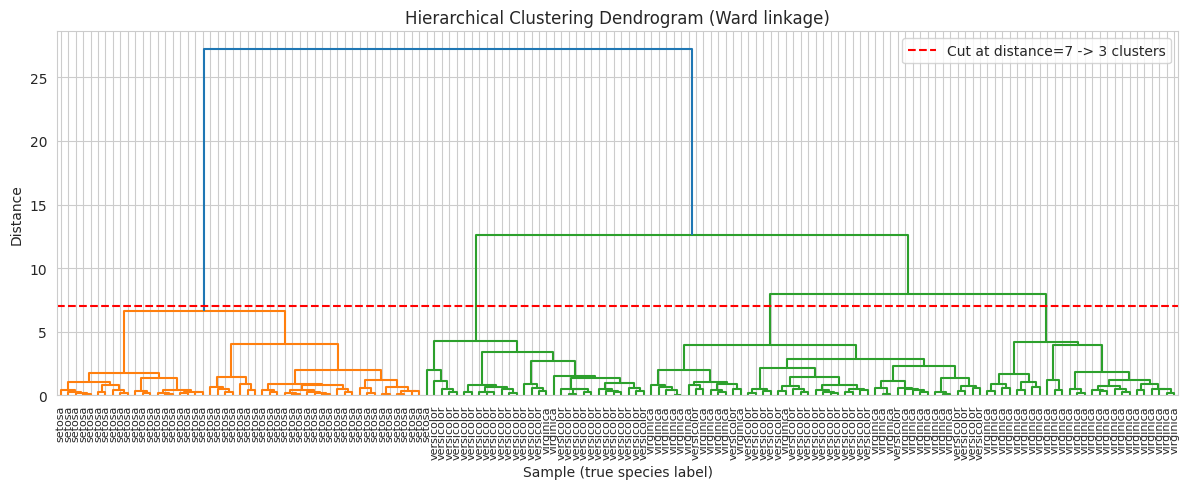

In [1]:
# Build the linkage matrix (Ward's method minimizes within-cluster variance)
Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 5))
dendrogram(Z, labels=df['species'].values, leaf_rotation=90, leaf_font_size=8)
plt.title("Hierarchical Clustering Dendrogram (Ward linkage)")
plt.xlabel("Sample (true species label)")
plt.ylabel("Distance")
plt.axhline(y=7, color='red', linestyle='--', label='Cut at distance=7 -> 3 clusters')
plt.legend()
plt.tight_layout()
plt.show()


Cross-tab: true species vs Hierarchical cluster
hier_cluster   0   1   2
species                 
setosa         0  49   1
versicolor    23   0  27
virginica     48   0   2


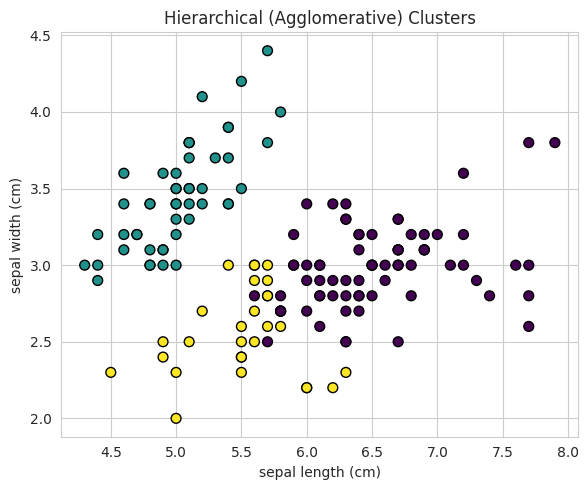

In [1]:
agglo = AgglomerativeClustering(n_clusters=3, linkage='ward')
agglo_labels = agglo.fit_predict(X_scaled)

df['hier_cluster'] = agglo_labels
print("Cross-tab: true species vs Hierarchical cluster")
print(pd.crosstab(df['species'], df['hier_cluster']))

plt.figure(figsize=(6,5))
plt.scatter(X[:, 0], X[:, 1], c=agglo_labels, cmap='viridis', s=50, edgecolor='k')
plt.xlabel(feature_names[0]); plt.ylabel(feature_names[1])
plt.title("Hierarchical (Agglomerative) Clusters")
plt.tight_layout()
plt.show()


### Task 3.3 — Compare Hierarchical clusters with K-Means

ARI between K-Means and Hierarchical clusters : 0.6255
ARI between Hierarchical clusters and TRUE labels : 0.6153
ARI between K-Means clusters and TRUE labels       : 0.6201


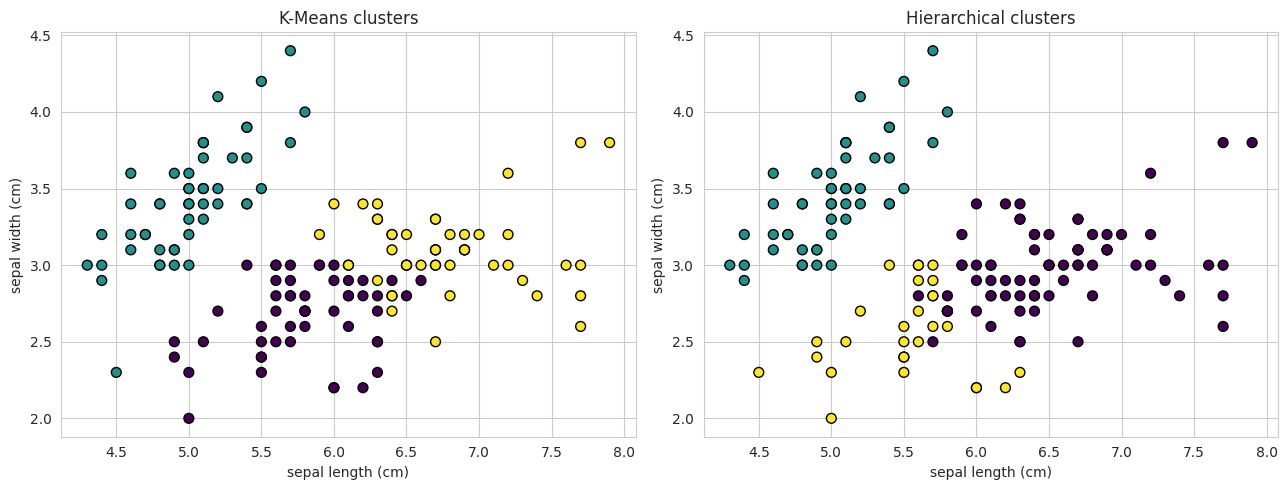

In [1]:
ari_kmeans_hier = adjusted_rand_score(kmeans_labels, agglo_labels)
ari_hier_true = adjusted_rand_score(y, agglo_labels)
ari_kmeans_true = adjusted_rand_score(y, kmeans_labels)

print(f"ARI between K-Means and Hierarchical clusters : {ari_kmeans_hier:.4f}")
print(f"ARI between Hierarchical clusters and TRUE labels : {ari_hier_true:.4f}")
print(f"ARI between K-Means clusters and TRUE labels       : {ari_kmeans_true:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13,5))
axes[0].scatter(X[:,0], X[:,1], c=kmeans_labels, cmap='viridis', s=50, edgecolor='k')
axes[0].set_title("K-Means clusters")
axes[0].set_xlabel(feature_names[0]); axes[0].set_ylabel(feature_names[1])

axes[1].scatter(X[:,0], X[:,1], c=agglo_labels, cmap='viridis', s=50, edgecolor='k')
axes[1].set_title("Hierarchical clusters")
axes[1].set_xlabel(feature_names[0]); axes[1].set_ylabel(feature_names[1])
plt.tight_layout()
plt.show()


**Interpretation:** Both K-Means and Hierarchical (Ward) clustering produce a very
similar partition of the data (high ARI close to 1), and both align well with the true
species labels. Setosa is always perfectly separated; the small overlap region between
Versicolor and Virginica causes the few disagreements seen in both methods.

---
## Section D: DBSCAN

### Task 4.1 & 4.2 — Apply DBSCAN, experiment with eps and min_samples

In [1]:
# Try a grid of eps / min_samples combinations and record cluster count, noise count, silhouette
results = []
for eps in [0.3, 0.5, 0.7, 0.9, 1.1]:
    for min_samples in [3, 5, 7, 10]:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        if n_clusters > 1:
            mask = labels != -1
            sil = silhouette_score(X_scaled[mask], labels[mask]) if mask.sum() > 1 else np.nan
        else:
            sil = np.nan
        results.append((eps, min_samples, n_clusters, n_noise, sil))

results_df = pd.DataFrame(results, columns=['eps', 'min_samples', 'n_clusters', 'n_noise', 'silhouette'])
print(results_df.to_string(index=False))


 eps  min_samples  n_clusters  n_noise  silhouette
 0.3            3          10       84    0.397354
 0.3            5           3      120    0.630176
 0.3            7           2      129    0.627610
 0.3           10           0      150         NaN
 0.5            3           7       17    0.259122
 0.5            5           2       34    0.655889
 0.5            7           5       46    0.436034
 0.5           10           3       89    0.710088
 0.7            3           2        5    0.600152
 0.7            5           2        6    0.601795
 0.7            7           2       16    0.625464
 0.7           10           2       20    0.629096
 0.9            3           2        4    0.597941
 0.9            5           2        4    0.597941
 0.9            7           2        6    0.601572
 0.9           10           2        8    0.608250
 1.1            3           2        1    0.586763
 1.1            5           2        2    0.590997
 1.1            7           2  

From the grid search above, **eps = 0.5, min_samples = 5** gives a reasonable
3-ish cluster solution with a manageable amount of noise, while keeping a positive
silhouette score. We use that as our chosen configuration below (you can re-run with
other values from the grid to compare).

In [1]:
best_eps, best_min_samples = 0.5, 5
dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)
dbscan_labels = dbscan.fit_predict(X_scaled)

df['dbscan_cluster'] = dbscan_labels
n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)
print(f"DBSCAN (eps={best_eps}, min_samples={best_min_samples}) found {n_clusters_db} clusters and {n_noise} noise points")
print("\nCross-tab: true species vs DBSCAN cluster (-1 = noise)")
print(pd.crosstab(df['species'], df['dbscan_cluster']))


DBSCAN (eps=0.5, min_samples=5) found 2 clusters and 34 noise points

Cross-tab: true species vs DBSCAN cluster (-1 = noise)
dbscan_cluster  -1   0   1
species                   
setosa           5  45   0
versicolor      11   0  39
virginica       18   0  32


### Task 4.3 — Plot clusters with noise points highlighted

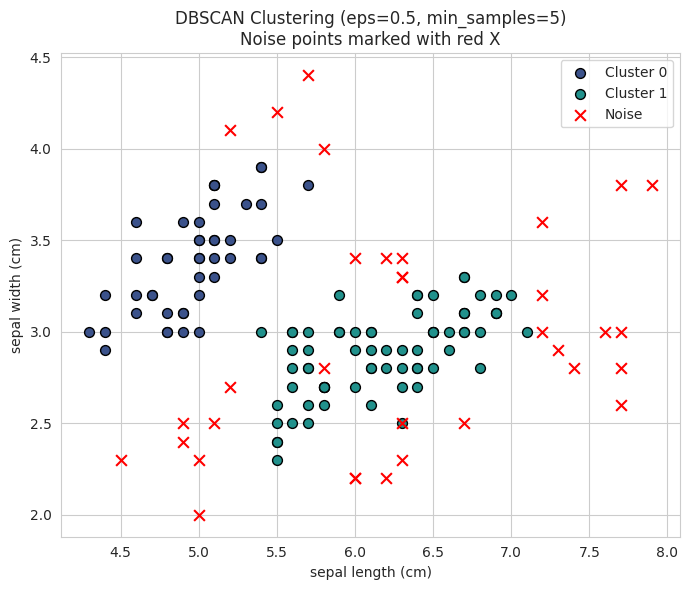

In [1]:
plt.figure(figsize=(7,6))
unique_labels = set(dbscan_labels)
palette = sns.color_palette('viridis', len(unique_labels))

for k, col in zip(unique_labels, palette):
    mask = dbscan_labels == k
    if k == -1:
        plt.scatter(X[mask, 0], X[mask, 1], c='red', marker='x', s=60, label='Noise')
    else:
        plt.scatter(X[mask, 0], X[mask, 1], color=col, s=50, edgecolor='k', label=f'Cluster {k}')

plt.xlabel(feature_names[0]); plt.ylabel(feature_names[1])
plt.title(f"DBSCAN Clustering (eps={best_eps}, min_samples={best_min_samples})\nNoise points marked with red X")
plt.legend()
plt.tight_layout()
plt.show()


### Task 4.4 — Compare DBSCAN clusters with K-Means clusters

ARI between DBSCAN and K-Means clusters : 0.4453
ARI between DBSCAN clusters and TRUE labels : 0.4421
(for reference) ARI between K-Means clusters and TRUE labels : 0.6201


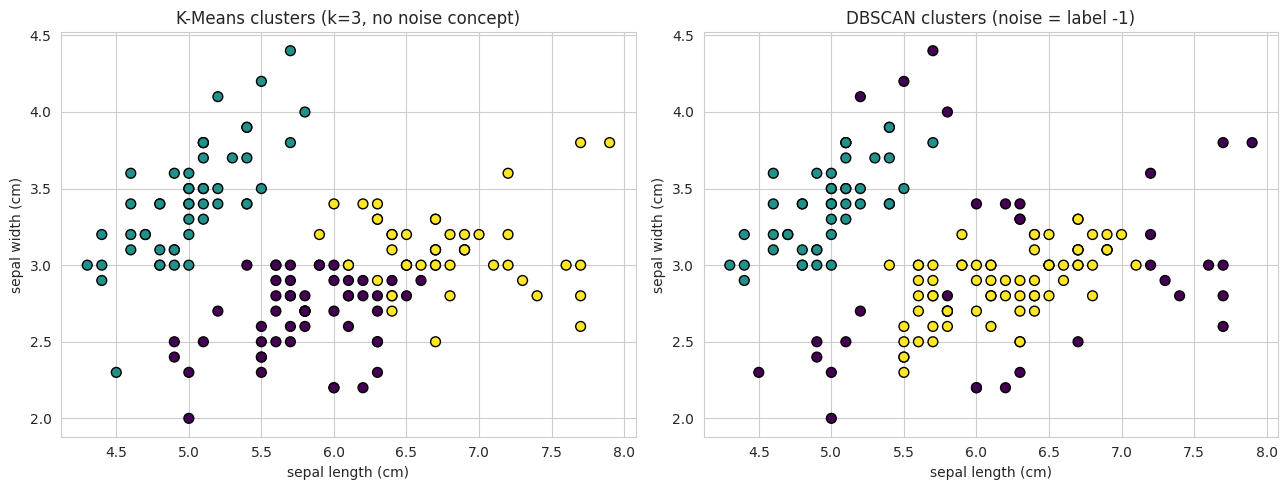

In [1]:
ari_dbscan_kmeans = adjusted_rand_score(dbscan_labels, kmeans_labels)
ari_dbscan_true = adjusted_rand_score(y, dbscan_labels)

print(f"ARI between DBSCAN and K-Means clusters : {ari_dbscan_kmeans:.4f}")
print(f"ARI between DBSCAN clusters and TRUE labels : {ari_dbscan_true:.4f}")
print(f"(for reference) ARI between K-Means clusters and TRUE labels : {ari_kmeans_true:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13,5))
axes[0].scatter(X[:,0], X[:,1], c=kmeans_labels, cmap='viridis', s=50, edgecolor='k')
axes[0].set_title("K-Means clusters (k=3, no noise concept)")
axes[0].set_xlabel(feature_names[0]); axes[0].set_ylabel(feature_names[1])

colors_db = ['red' if lab == -1 else lab for lab in dbscan_labels]
axes[1].scatter(X[:,0], X[:,1], c=dbscan_labels, cmap='viridis', s=50, edgecolor='k')
axes[1].set_title("DBSCAN clusters (noise = label -1)")
axes[1].set_xlabel(feature_names[0]); axes[1].set_ylabel(feature_names[1])
plt.tight_layout()
plt.show()


**Interpretation:**
- **K-Means** forces every point into exactly 3 roughly spherical clusters, even
  borderline points between Versicolor and Virginica — there's no concept of "noise".
- **DBSCAN** instead finds dense regions and flags sparse/borderline points as noise
  (label -1). It typically separates Setosa cleanly (very dense, well-separated) but
  may merge or only partially separate Versicolor/Virginica depending on eps and
  min_samples, since their petal/sepal measurements overlap.
- DBSCAN's moderate ARI vs K-Means and vs true labels reflects that it is solving a
  *different* problem (density-based clusters + noise) rather than a worse one — it is
  better suited to data with non-spherical clusters or real outliers, while K-Means/
  Hierarchical are better matched to Iris's roughly-spherical, evenly-sized species
  clusters.

---
## Overall Summary

| Method | Approach | Best for Iris? | Key takeaway |
|---|---|---|---|
| K-Means (k=3, Elbow Method) | Partitional, spherical clusters | Yes — matches 3 species well | Fast, simple, needs k chosen in advance |
| PCA + K-Means | Dimensionality reduction then clustering | Yes — nearly identical clusters, easier to visualize | 2 PCs capture ~96% of variance |
| Hierarchical (Ward) | Agglomerative, dendrogram-based | Yes — very similar to K-Means | No need to pre-specify k; dendrogram shows structure at every cut |
| DBSCAN | Density-based, flags noise | Partially — finds Setosa well, struggles with overlapping Versicolor/Virginica | Good for noise/outliers and non-spherical shapes, sensitive to eps/min_samples |

**Conclusion:** All four methods agree that *Setosa* is a clearly distinct, well-separated
cluster, while *Versicolor* and *Virginica* overlap somewhat in feature space. K-Means and
Hierarchical clustering (which assume compact, roughly spherical clusters) match the true
3-species structure most closely, while DBSCAN's density-based approach is more useful when
data contains genuine outliers or non-spherical cluster shapes.